In [1]:
import sys
sys.path.insert(0, '/home/svu/e1498138/localgit/PTA/waveform/GWhyp/src')
from gw_hyp import get_hyp_waveform as gywq, cal_sp_sx, cal_sp_sx_A, hyp_pta_res
from constants import *
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt

In [2]:
M=1e10  # two equal mass BHs with M=10^10 Msun
#q=1
et0=1.1
b_1=51
b_2=70
b_3=107.56
ti=-2
tf=2
t_step=1000
inc=np.pi/3
distance=5
order=3
# from mj
chi1 = 0.95
chi2 = 0.85 #lower and upper bounds for M87 spin, https://arxiv.org/pdf/1904.07923
chiA = 0.5 * (chi1 - chi2)
chiS = 0.5 * (chi1 + chi2)


In [3]:
def q_from_eta(eta):
    delta = sqrt(1 - 4*eta)
    return (1 - 2*eta + delta) / (2*eta)

eta=0.25 #equal mass BH
q=q_from_eta(eta)
delta=sqrt(1-4*eta)
q,delta

(np.float64(1.0), np.float64(0.0))

In [4]:

D_GW = 1.6e9 * pc          # distance in metres (e.g. 1.6 Gpc)
tarr = np.linspace(ti, tf, t_step) * yr

x0_1 = np.sqrt(et0**2 - 1) / b_1
n0_1 = x0_1**(3/2) / (M * tsun) # mean motion in 1/s

def meanmot(b, et0):
    x0=np.sqrt(et0**2 - 1) / b
    n0=x0**(3/2)/(M*tsun)
    return n0

In [5]:
Hp1, Hx1 = gywq(M, q, et0, meanmot(b_1,et0), tarr, inc, D_GW, delta=delta, chi_A=chiA, chi_S=chiS)
Hp2, Hx2 = gywq(M, q, et0,  meanmot(b_2,et0), tarr, inc, D_GW, delta=delta, chi_A=chiA, chi_S=chiS)
Hp3, Hx3 = gywq(M, q, et0,  meanmot(b_3,et0), tarr, inc, D_GW, delta=delta, chi_A=chiA, chi_S=chiS)


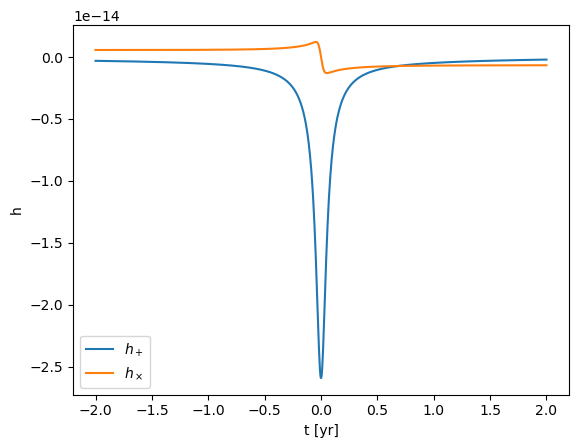

In [6]:
plt.figure()
plt.plot(tarr/yr, Hp1, label=r'$h_+$')
plt.plot(tarr/yr, Hx1, label=r'$h_\times$')
plt.xlabel('t [yr]')
plt.ylabel('h')
plt.legend()
plt.show()

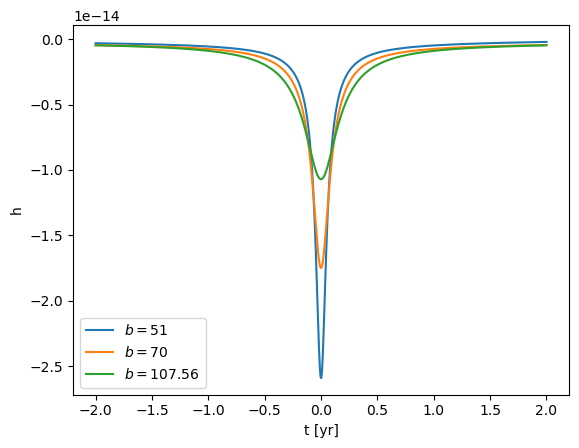

In [7]:
plt.figure()
plt.plot(tarr/yr, Hp1, label=r'$b=51$')
plt.plot(tarr/yr, Hp2, label=r'$b=70$')
plt.plot(tarr/yr, Hp3, label=r'$b=107.56$')

plt.xlabel('t [yr]')
plt.ylabel('h')
plt.legend()
plt.show()